In [1]:
import pandas
from datetime import datetime
from pytz import utc
import matplotlib.pyplot as plt

data = pandas.read_csv('../Seccion_20/data/reviews.csv')
data.head()

,Course Name,Timestamp,Rating,Comment
0,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 06:25:52+00:00,4.0,NaN
1,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:12:34+00:00,4.0,NaN
2,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:11:03+00:00,4.0,NaN
3,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:33:24+00:00,5.0,NaN
4,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:31:49+00:00,4.5,NaN


,Course Name,Timestamp,Rating,Comment
Day,,,,
2018-01-01,46,46,46,7
2018-01-02,57,57,57,16
2018-01-03,43,43,43,8
2018-01-04,48,48,48,11
2018-01-05,52,52,52,15


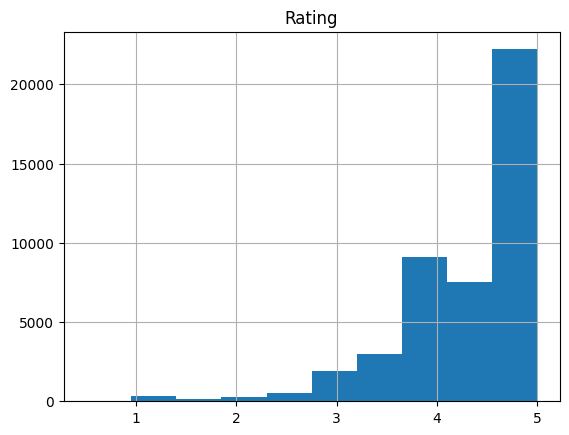

In [2]:
data.hist('Rating') # Create a histogram of the 'Rating' column

# Convert Timestamp column to datetime format first
data['Timestamp'] = pandas.to_datetime(data['Timestamp'])

data['Day'] = data['Timestamp'].dt.date # Extract date from 'Timestamp' and create a new 'Day' column
day_average = data.groupby('Day').count() # Group by 'Day' and calculate mean for each day
day_average.head() # Display the first few rows of the daily average ratings

### Plot 'Timestamp' vs 'Rating'

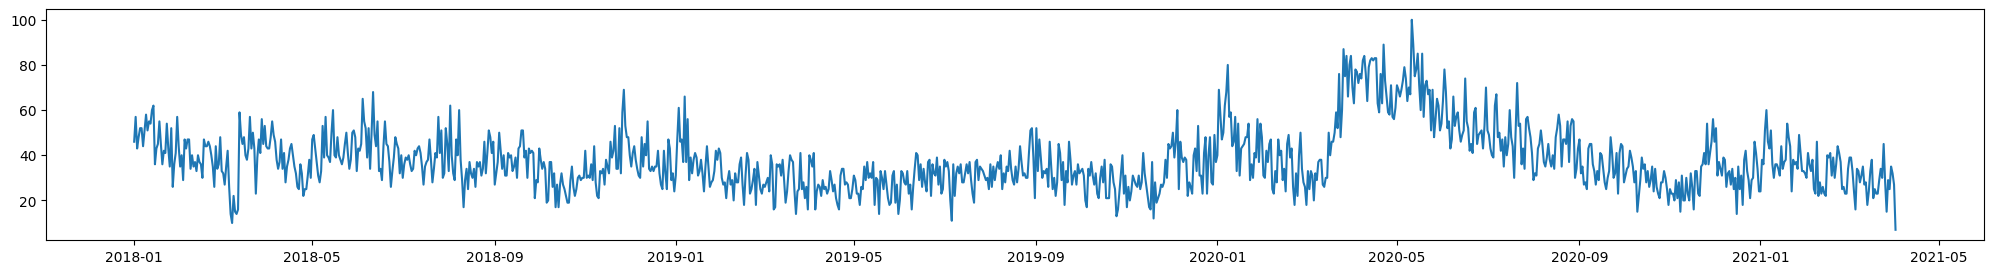

In [3]:
plt.figure(figsize=(25,3)) # Set the figure size
plt.plot(day_average.index, day_average['Rating']) # Plot 'Timestamp' vs 'Rating'

### Rating average by week

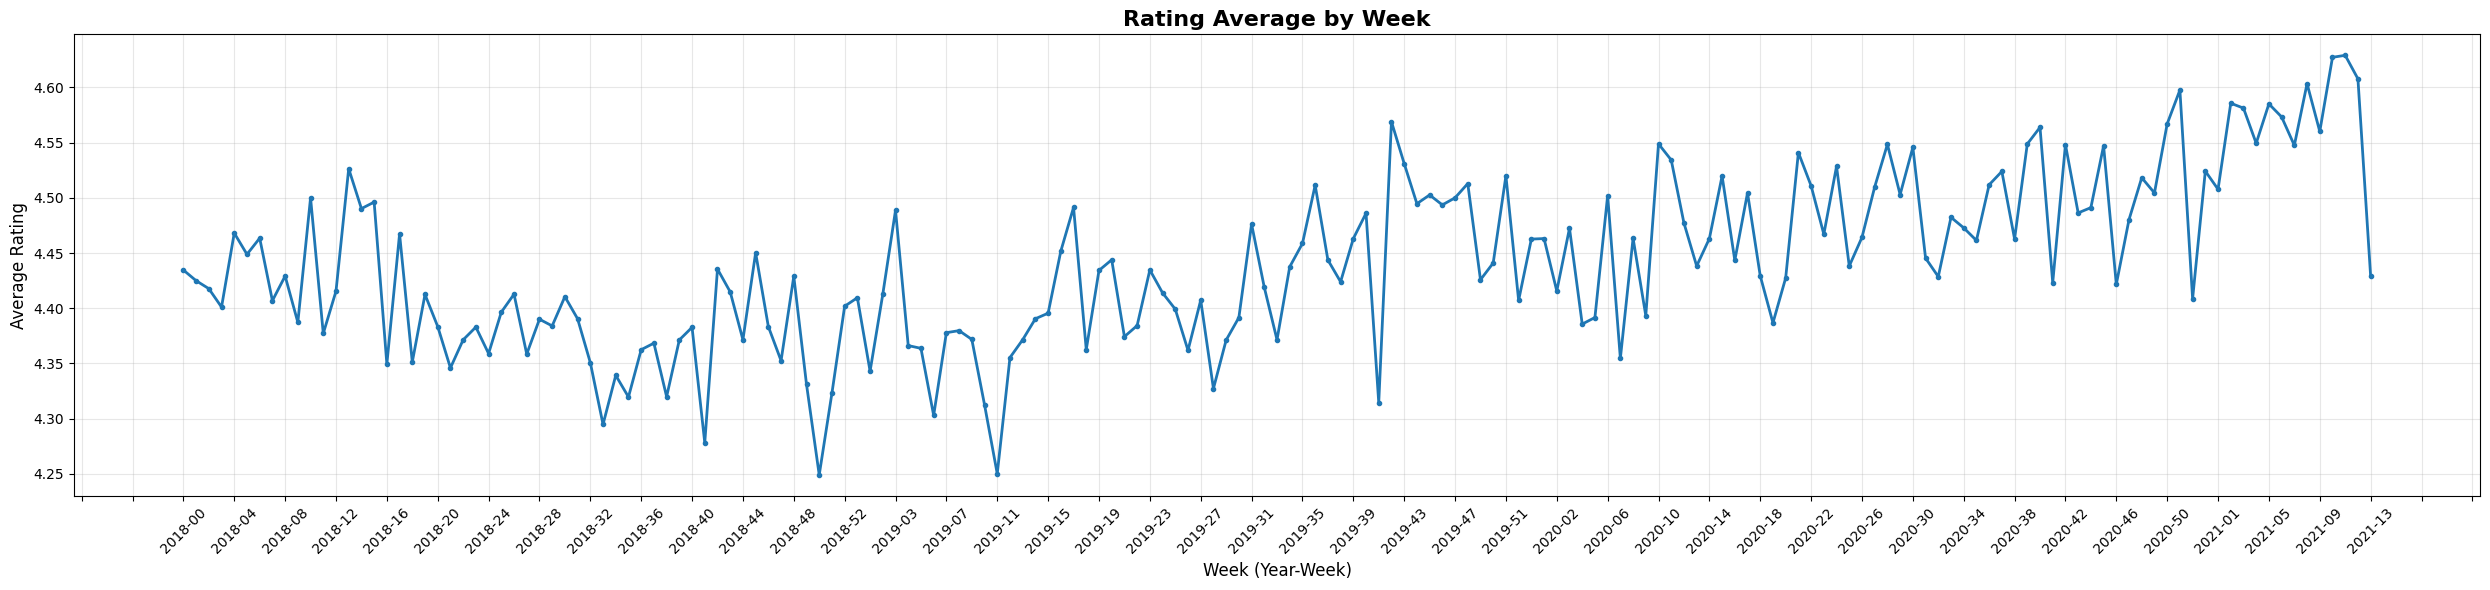

In [6]:
# Extract week from timestamp and create a new 'Week' column

# First form with week number
# data['Week'] = data['Timestamp'].dt.isocalendar().week

# Second form with year and week number
data['Week'] = data['Timestamp'].dt.strftime('%Y-%U')

# Group by 'Week' and calculate mean rating for each week
week_average = data.groupby('Week')['Rating'].mean()

# Create improved plot
plt.figure(figsize=(25,6)) # Increase height for better visibility
plt.plot(week_average.index, week_average, marker='o', linewidth=2, markersize=3)

# Improve x-axis labels
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(4))  # Show every 4th week

# Add titles and labels
plt.title('Rating Average by Week', fontsize=16, fontweight='bold')
plt.xlabel('Week (Year-Week)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# Improve grid and layout
plt.grid(True, alpha=0.3)
plt.tight_layout()  # Adjust layout to prevent label cutoff

plt.show()

### Average rating by month 

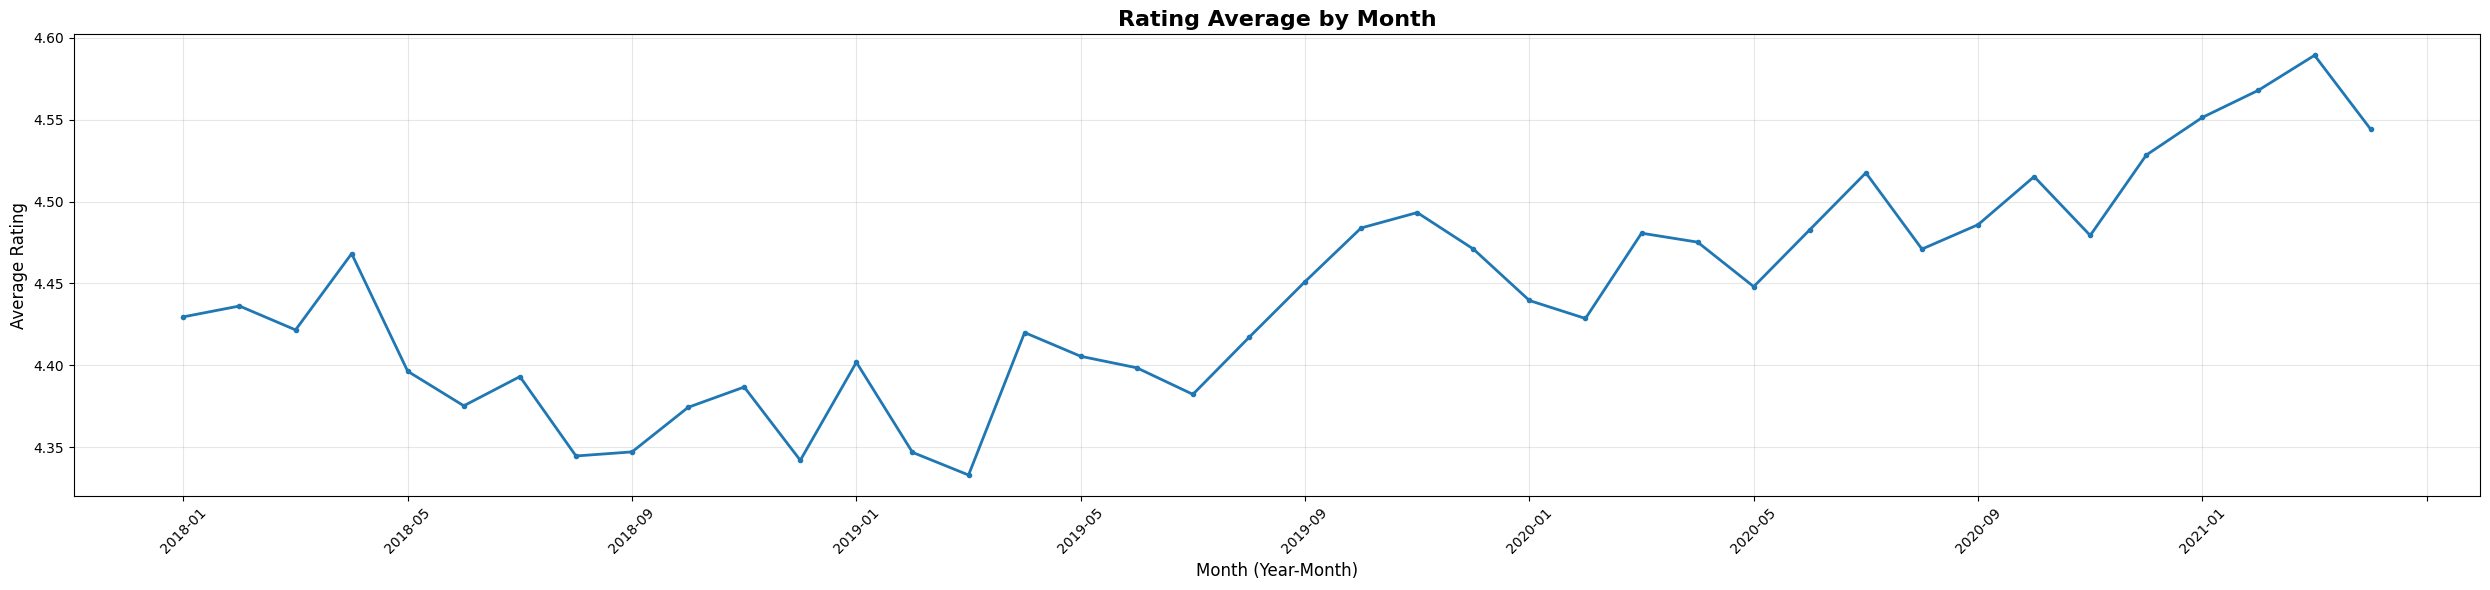

In [8]:
# Extract week from timestamp and create a new 'Week' column

# First form with week number
# data['Month'] = data['Timestamp'].dt.isocalendar().month

# Second form with year and week number
data['Month'] = data['Timestamp'].dt.strftime('%Y-%m')

# Group by 'Month' and calculate mean rating for each month
month_average = data.groupby('Month')['Rating'].mean()

# Create improved plot
plt.figure(figsize=(25,6)) # Increase height for better visibility
plt.plot(month_average.index, month_average, marker='o', linewidth=2, markersize=3)

# Improve x-axis labels
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(4))  # Show every 4th month

# Add titles and labels
plt.title('Rating Average by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month (Year-Month)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# Improve grid and layout
plt.grid(True, alpha=0.3)
plt.tight_layout()  # Adjust layout to prevent label cutoff

plt.show()

### Avergae rating by month by course

<Axes: xlabel='Month'>

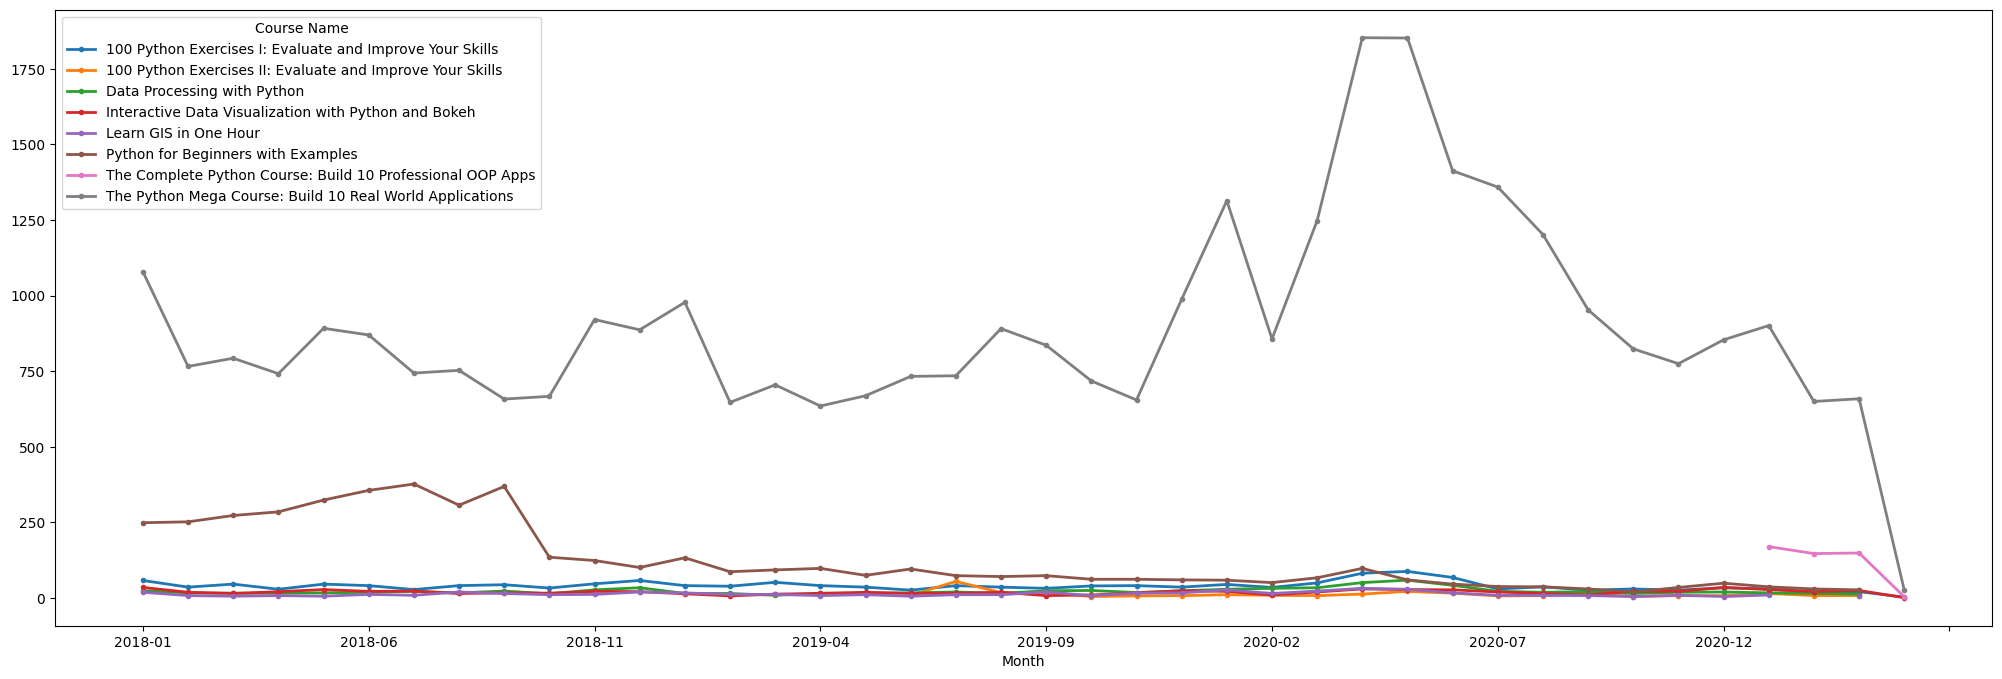

In [15]:
data['Month'] = data['Timestamp'].dt.strftime('%Y-%m')
month_average_crs = data.groupby(['Month', 'Course Name'])['Rating'].count().unstack()

month_average_crs.plot(figsize=(25,8), marker='o', linewidth=2, markersize=3)

### What day are people the happiest?

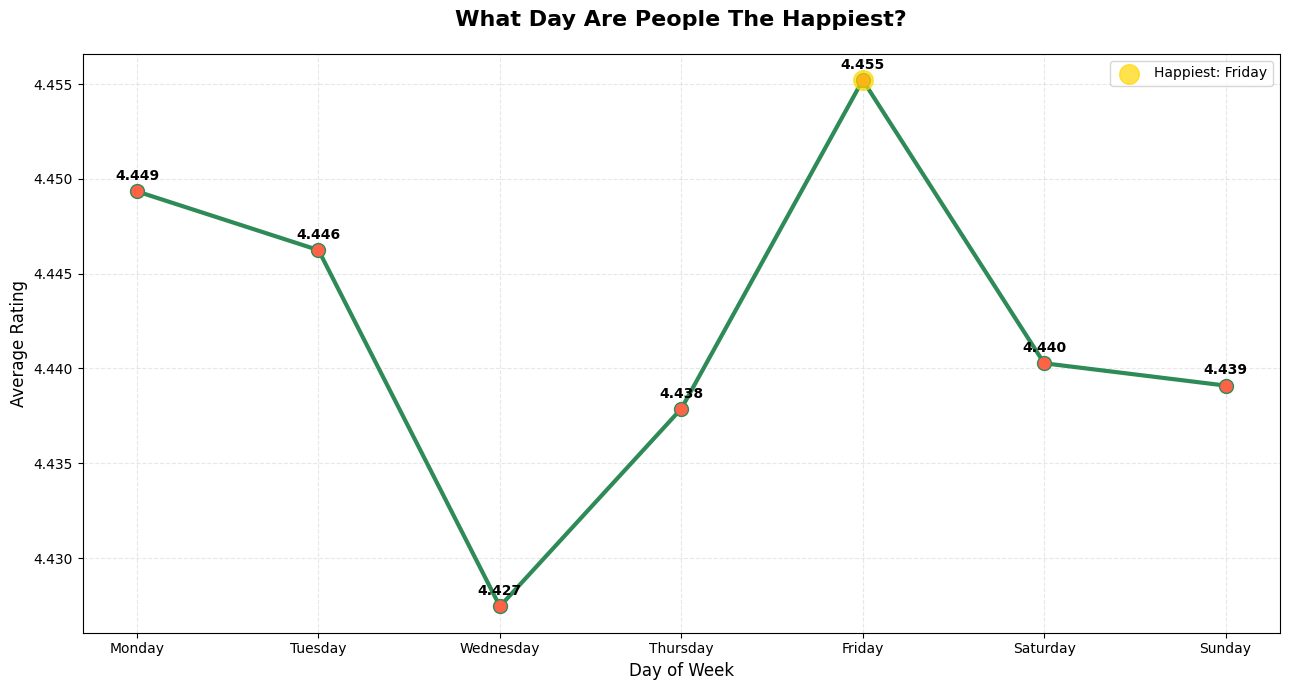

In [25]:
# Extract weekday and analyze happiness by day of week
data['Weekday'] = data['Timestamp'].dt.strftime('%A') # Create a 'Weekday' column with full weekday names

# Calculate average rating by weekday
week_average = data.groupby('Weekday')['Rating'].mean()

# Define correct order for weekdays (Monday to Sunday)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reorder the data according to weekday order
week_average = week_average.reindex(weekday_order)

# Create improved plot
plt.figure(figsize=(13, 7)) # Increased height to give more space
plt.plot(week_average.index, week_average, marker='o', linewidth=3, markersize=10, color='#2E8B57', markerfacecolor='#FF6347')

# Improve styling
plt.title('What Day Are People The Happiest?', fontsize=16, fontweight='bold', pad=20) # Added padding to title
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=0)

# Add value labels on points (reduced vertical offset)
for i, v in enumerate(week_average.values):
    plt.annotate(f'{v:.3f}', 
                (week_average.index[i], v), 
                textcoords="offset points", 
                xytext=(0,8),  # Reduced from 15 to 8
                ha='center',
                fontweight='bold',
                fontsize=10)

# Highlight the happiest day
happiest_day = week_average.idxmax()
happiest_rating = week_average.max()
plt.scatter(happiest_day, happiest_rating, color='gold', s=200, zorder=5, alpha=0.7, label=f'Happiest: {happiest_day}')

plt.legend()
plt.tight_layout()
plt.show()

### Number of raitin by course

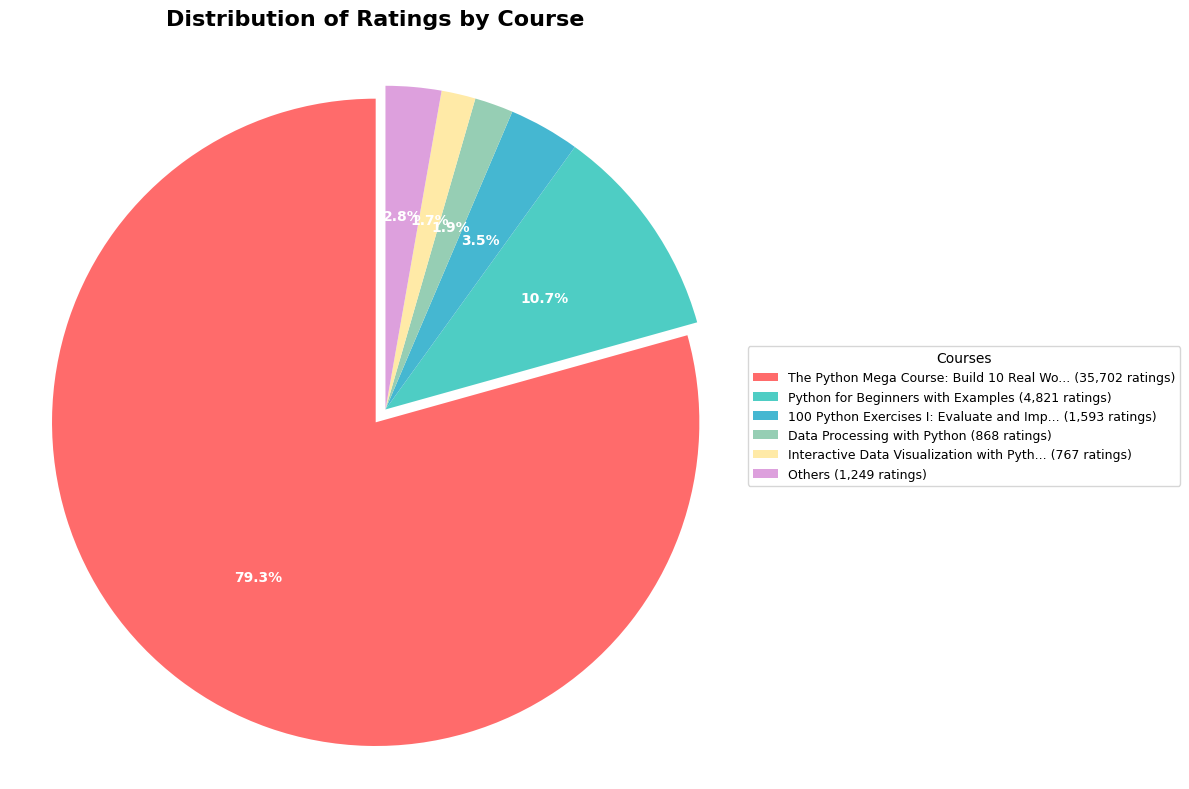


Total ratings: 45,000
Number of courses: 8

Top course: The Python Mega Course: Build 10 Real World Applications (35,702 ratings - 79.3%)


In [34]:
# Count ratings by course
share = data.groupby('Course Name')['Rating'].count().sort_values(ascending=False)

# Group smaller courses into "Others" category for better readability
top_courses = share.head(5)  # Show top 5 courses
others_count = share.tail(-5).sum()  # Sum the rest

# Create final data for pie chart
if others_count > 0:
    pie_data = top_courses.copy()
    pie_data['Others'] = others_count
else:
    pie_data = top_courses

# Create improved pie chart
plt.figure(figsize=(12, 8))

# Define custom colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

# Create pie chart with better formatting
wedges, texts, autotexts = plt.pie(pie_data.values, 
                                  labels=None,  # Don't show labels on pie
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=colors,
                                  explode=[0.05 if i == 0 else 0 for i in range(len(pie_data))],  # Explode largest slice
                                  textprops={'fontsize': 10, 'fontweight': 'bold'})

# Improve styling
plt.title('Distribution of Ratings by Course', fontsize=16, fontweight='bold', pad=20)

# Create legend with course names (shortened for readability)
legend_labels = []
for course, count in pie_data.items():
    if course == 'Others':
        legend_labels.append(f'{course} ({count:,} ratings)')
    else:
        # Shorten long course names
        short_name = course[:40] + '...' if len(course) > 40 else course
        legend_labels.append(f'{short_name} ({count:,} ratings)')

plt.legend(wedges, legend_labels, 
          title="Courses",
          loc="center left", 
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=9)

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal ratings: {share.sum():,}")
print(f"Number of courses: {len(share)}")
print(f"\nTop course: {share.index[0]} ({share.iloc[0]:,} ratings - {share.iloc[0]/share.sum()*100:.1f}%)")